***Step 6***

*Import data*

In [49]:
import pickle
import numpy as np
import gurobipy as gp
from gurobipy import GRB

with open("DA_results.pkl", "rb") as f:
    DA = pickle.load(f)

lambda_DA       = DA["lambda_"]
g_DA            = DA["DA_gen_disp"]
gen_cap_dict    = DA["DA_gen_cap"]
gen_costs       = DA["gen_costs"]
VARIABLES       = DA["VARIABLES"]
LOAD_VARIABLES  = DA["LOAD_VARIABLES"]
Wind_DA         = np.array(DA["Wind_DA"])
Load_percentage = DA["Load_percentage"]
hour1_load      = DA["hour1_load"]

conv_names = [v for v in VARIABLES if v.startswith('G')]
wind_names = [v for v in VARIABLES if v.startswith('W')]

print(f"DA clearing price: {lambda_DA:.2f} $/MWh")
print(f"Total load hour 1: {hour1_load:.2f} MW")

DA clearing price: 5.47 $/MWh
Total load hour 1: 1775.84 MW


**Reserve requirements**

In [50]:
R_up_req   = 0.15 * hour1_load   # upward reserve requirement
R_down_req = 0.10 * hour1_load   # downward reserve requirement

print(f"Upward reserve requirement:   {R_up_req:.2f} MW  (15% of {hour1_load:.2f} MW)")
print(f"Downward reserve requirement: {R_down_req:.2f} MW  (10% of {hour1_load:.2f} MW)")

Upward reserve requirement:   266.38 MW  (15% of 1775.84 MW)
Downward reserve requirement: 177.58 MW  (10% of 1775.84 MW)


**European style: reserve market first, then DA**

In [51]:
# ── STEP 6 EUROPEAN STYLE ──────────────────────────────────────────────
# Reserve market clears FIRST, committing capacity from the flexible subset.
# Remaining capacity then enters the DA energy market.

RESERVE_SUBSET = {'G1', 'G2', 'G3', 'G9', 'G10'}

# Reserve offer prices: assume generators offer reserves at their marginal cost
# Upward reserve: C_g (opportunity cost of holding capacity)
# Downward reserve: C_g

reserve_up_offers   = {}   # {g: (price $/MWh, max_MW)}
reserve_down_offers = {}   # {g: (price $/MWh, max_MW)}

for i, g in enumerate(conv_names):
    if g not in RESERVE_SUBSET:
        continue
    c_i     = gen_costs[g]
    g_max_i = gen_cap_dict[i]

    reserve_up_offers[g]   = (c_i, g_max_i)   # can offer up to full capacity
    reserve_down_offers[g] = (c_i, g_max_i)

print("Reserve up offers (price, max MW):")
for g, (p, mw) in reserve_up_offers.items():
    print(f"  {g}: {p:.2f} $/MWh  max {mw:.2f} MW")

print("\nReserve down offers (price, max MW):")
for g, (p, mw) in reserve_down_offers.items():
    print(f"  {g}: {p:.2f} $/MWh  max {mw:.2f} MW")

Reserve up offers (price, max MW):
  G1: 13.32 $/MWh  max 152.00 MW
  G2: 13.32 $/MWh  max 152.00 MW
  G3: 20.70 $/MWh  max 350.00 MW
  G9: 5.47 $/MWh  max 400.00 MW
  G10: 0.00 $/MWh  max 300.00 MW

Reserve down offers (price, max MW):
  G1: 13.32 $/MWh  max 152.00 MW
  G2: 13.32 $/MWh  max 152.00 MW
  G3: 20.70 $/MWh  max 350.00 MW
  G9: 5.47 $/MWh  max 400.00 MW
  G10: 0.00 $/MWh  max 300.00 MW


***Solve European Model***

In [52]:
model_R = gp.Model("ReserveMarket_European")
model_R.Params.OutputFlag = 0

# Reserve capacity variables
r_up   = {g: model_R.addVar(lb=0, ub=mw, name=f'rup_{g}')
          for g, (p, mw) in reserve_up_offers.items()}
r_down = {g: model_R.addVar(lb=0, ub=mw, name=f'rdn_{g}')
          for g, (p, mw) in reserve_down_offers.items()}

# Must meet reserve requirements
model_R.addConstr(gp.quicksum(r_up[g]   for g in r_up)   >= R_up_req,   name="req_up")
model_R.addConstr(gp.quicksum(r_down[g] for g in r_down) >= R_down_req, name="req_down")

# Minimise cost of procuring reserves
obj_R = (gp.quicksum(reserve_up_offers[g][0]   * r_up[g]   for g in r_up) +
         gp.quicksum(reserve_down_offers[g][0]  * r_down[g] for g in r_down))

model_R.setObjective(obj_R, GRB.MINIMIZE)
model_R.optimize()

# Reserve clearing prices (duals)
lambda_R_up   = model_R.getConstrByName("req_up").Pi
lambda_R_down = model_R.getConstrByName("req_down").Pi

print(f"Reserve up   clearing price: {lambda_R_up:.2f} $/MWh")
print(f"Reserve down clearing price: {lambda_R_down:.2f} $/MWh")
print(f"\nCommitted reserve capacity:")
for g in r_up:
    print(f"  {g}: up={r_up[g].X:.2f} MW  |  down={r_down[g].X:.2f} MW")

# Store committed reserve per generator — this capacity is locked out of DA
reserved_up   = {g: r_up[g].X   for g in r_up}
reserved_down = {g: r_down[g].X for g in r_down}

Reserve up   clearing price: 0.00 $/MWh
Reserve down clearing price: 0.00 $/MWh

Committed reserve capacity:
  G1: up=0.00 MW  |  down=0.00 MW
  G2: up=0.00 MW  |  down=0.00 MW
  G3: up=0.00 MW  |  down=0.00 MW
  G9: up=0.00 MW  |  down=0.00 MW
  G10: up=300.00 MW  |  down=300.00 MW


***Solve DA market with reduced capacity (European sequential)***

In [53]:
model_DA_eu = gp.Model("DA_European_AfterReserve")
model_DA_eu.Params.OutputFlag = 0

p_da = {}
for i, g in enumerate(conv_names):
    c_i     = gen_costs[g]
    g_max_i = gen_cap_dict[i]

    # Capacity available for DA = full capacity minus what is locked as reserve
    locked = reserved_up.get(g, 0) + reserved_down.get(g, 0)
    avail  = max(g_max_i - locked, 0)

    p_da[g] = model_DA_eu.addVar(lb=0, ub=avail, name=f'p_{g}')

# Wind — unconstrained by reserve
for w in wind_names:
    wi = list(wind_names).index(w)
    p_da[w] = model_DA_eu.addVar(lb=0, ub=Wind_DA[wi], name=f'p_{w}')

# Demand balance
total_demand = hour1_load
model_DA_eu.addConstr(
    gp.quicksum(p_da[v] for v in p_da) == total_demand,
    name="balance"
)

# Minimise generation cost
obj_DA = gp.quicksum(gen_costs.get(g, 0) * p_da[g] for g in p_da)
model_DA_eu.setObjective(obj_DA, GRB.MINIMIZE)
model_DA_eu.optimize()

lambda_DA_eu = model_DA_eu.getConstrByName("balance").Pi

print(f"DA clearing price (European, after reserve): {lambda_DA_eu:.2f} $/MWh")
print(f"(Original DA price without reserve:          {lambda_DA:.2f} $/MWh)")
print(f"\nDA dispatch (European sequential):")
for v in p_da:
    if p_da[v].X > 1e-3:
        print(f"  {v}: {p_da[v].X:.2f} MW")

DA clearing price (European, after reserve): 10.52 $/MWh
(Original DA price without reserve:          5.47 $/MWh)

DA dispatch (European sequential):
  G8: 400.00 MW
  G9: 400.00 MW
  G11: 226.08 MW
  W1: 118.54 MW
  W2: 139.64 MW
  W3: 135.50 MW
  W4: 102.78 MW
  W5: 131.60 MW
  W6: 121.69 MW


***US style: joint reserve + energy market***

In [ ]:
# ── STEP 6 US STYLE ───────────────────────────────────────────────────
# Reserve and energy cleared simultaneously in a single optimisation.
# Each generator submits one offer covering both energy and reserve capacity.
# The model decides the split between energy dispatch and reserve commitment.

model_US = gp.Model("Joint_Reserve_Energy_US")
model_US.Params.OutputFlag = 0

p_e  = {}   # energy dispatch
p_ru = {}   # upward reserve
p_rd = {}   # downward reserve

for i, g in enumerate(conv_names):
    g_max_i = gen_cap_dict[i]
    p_e[g]  = model_US.addVar(lb=0, name=f'e_{g}')
    p_ru[g] = model_US.addVar(lb=0, name=f'ru_{g}')
    p_rd[g] = model_US.addVar(lb=0, name=f'rd_{g}')

    # Capacity constraint: energy + upward reserve ≤ Pmax
    model_US.addConstr(p_e[g] + p_ru[g] <= g_max_i, name=f'cap_up_{g}')
    # Downward reserve ≤ energy dispatched (can only reduce what you produce)
    model_US.addConstr(p_rd[g] <= p_e[g],            name=f'cap_dn_{g}')

    # Only reserve subset can offer reserves
    if g not in RESERVE_SUBSET:
        model_US.addConstr(p_ru[g] == 0)
        model_US.addConstr(p_rd[g] == 0)

# Wind — energy only
p_w = {}
for wi, w in enumerate(wind_names):
    p_w[w] = model_US.addVar(lb=0, ub=Wind_DA[wi], name=f'e_{w}')

# Energy balance
model_US.addConstr(
    gp.quicksum(p_e[g] for g in p_e) + gp.quicksum(p_w[w] for w in p_w) == total_demand,
    name="energy_balance"
)

# Reserve requirements
model_US.addConstr(gp.quicksum(p_ru[g] for g in p_ru) >= R_up_req,   name="res_up")
model_US.addConstr(gp.quicksum(p_rd[g] for g in p_rd) >= R_down_req, name="res_down")

# Objective: minimise total cost (energy + reserve opportunity cost)
obj_US = gp.quicksum(gen_costs[g] * (p_e[g] + p_ru[g] + p_rd[g]) for g in p_e)
model_US.setObjective(obj_US, GRB.MINIMIZE)
model_US.optimize()

lambda_energy_US  = model_US.getConstrByName("energy_balance").Pi
lambda_res_up_US  = model_US.getConstrByName("res_up").Pi
lambda_res_dn_US  = model_US.getConstrByName("res_down").Pi

print(f"US-style joint market results:")
print(f"  Energy clearing price:        {lambda_energy_US:.2f} $/MWh")
print(f"  Upward reserve price:         {lambda_res_up_US:.2f} $/MWh")
print(f"  Downward reserve price:       {lambda_res_dn_US:.2f} $/MWh")
print(f"\n  Dispatch:")
for g in p_e:
    if p_e[g].X > 1e-3 or p_ru[g].X > 1e-3 or p_rd[g].X > 1e-3:
        print(f"  {g}: energy={p_e[g].X:.2f} MW  r_up={p_ru[g].X:.2f} MW  r_dn={p_rd[g].X:.2f} MW")
for w in p_w:
    if p_w[w].X > 1e-3:
        print(f"  {w}: energy={p_w[w].X:.2f} MW")

US-style joint market results:
  Energy clearing price:        10.52 $/MWh
  Upward reserve price:         10.52 $/MWh
  Downward reserve price:       -0.00 $/MWh

  Dispatch:
  G8: energy=400.00 MW  r_up=0.00 MW  r_dn=0.00 MW
  G9: energy=256.04 MW  r_up=143.96 MW  r_dn=0.00 MW
  G10: energy=177.58 MW  r_up=122.42 MW  r_dn=177.58 MW
  G11: energy=192.45 MW  r_up=0.00 MW  r_dn=0.00 MW
  W1: energy=118.54 MW
  W2: energy=139.64 MW
  W3: energy=135.50 MW
  W4: energy=102.78 MW
  W5: energy=131.60 MW
  W6: energy=121.69 MW


***European sequential vs US joint***

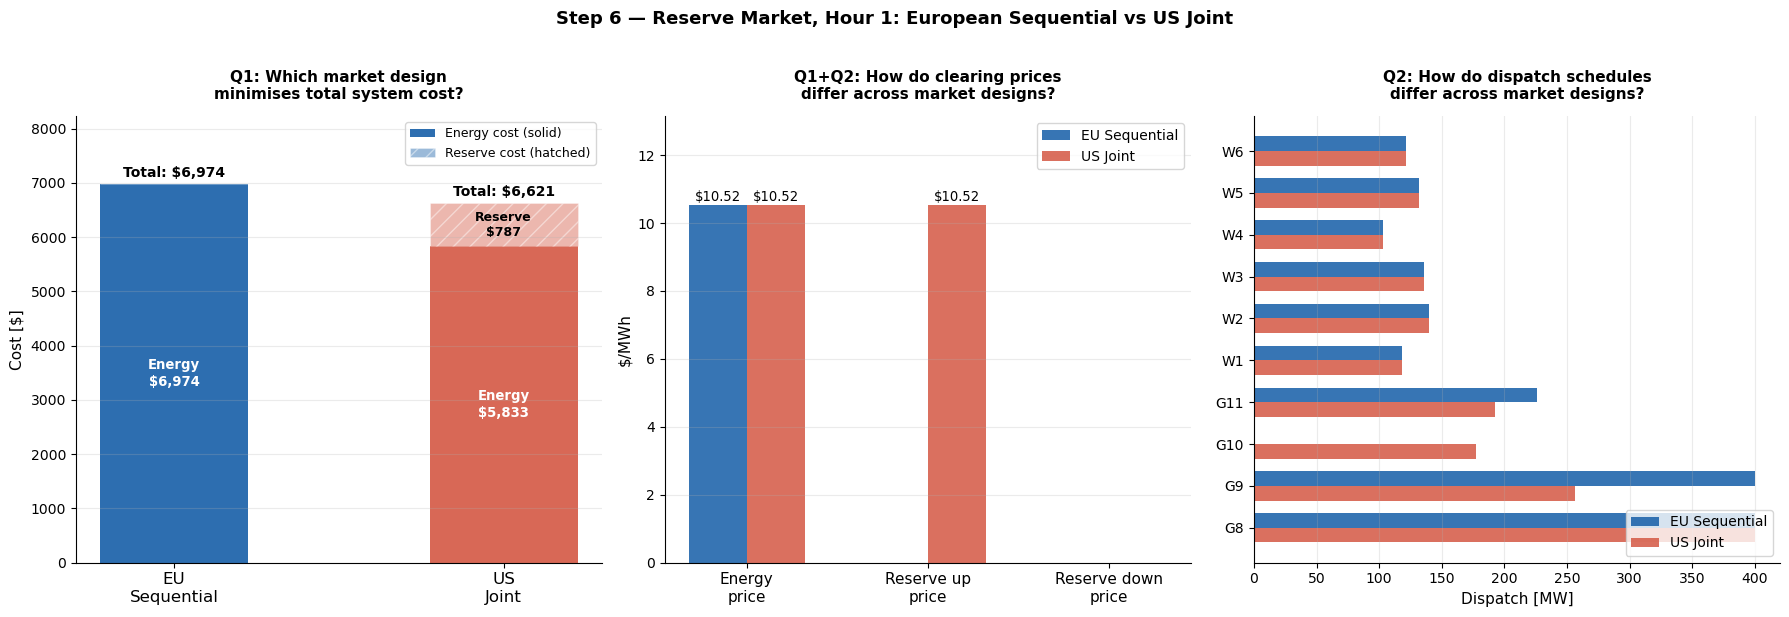

Saved: step6_comparison.png


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── DATA ─────────────────────────────────────────────────────────────
energy_cost_eu = sum(gen_costs.get(g, 0) * p_da[g].X for g in p_da)
energy_cost_us = sum(gen_costs[g] * p_e[g].X for g in p_e)
net_eu = sw_eu - rc_eu
net_us = sw_us - rc_us

models = ['EU\nSequential', 'US\nJoint']
colors_eu = '#2166ac'
colors_us = '#d6604d'

# ── PLOT 1: System cost breakdown (answers: which model is cheaper?) ──
en_costs    = [energy_cost_eu, energy_cost_us]
res_costs   = [rc_eu,          rc_us]
total_costs = [energy_cost_eu + rc_eu, energy_cost_us + rc_us]

ax = axes[0]
bar_w = 0.45
x = np.array([0, 1])

b_e = ax.bar(x, en_costs,  bar_w, color=[colors_eu, colors_us], alpha=0.95)
b_r = ax.bar(x, res_costs, bar_w, bottom=en_costs,
             color=[colors_eu, colors_us], alpha=0.45,
             hatch='//', edgecolor='white', linewidth=0.5)

# Segment labels
for i, (ec, rc, tc) in enumerate(zip(en_costs, res_costs, total_costs)):
    ax.text(i, ec / 2, f'Energy\n${ec:,.0f}',
            ha='center', va='center', fontsize=9.5,
            fontweight='bold', color='white')
    if rc > 30:
        ax.text(i, ec + rc / 2, f'Reserve\n${rc:,.0f}',
                ha='center', va='center', fontsize=9,
                fontweight='bold', color='black')
    ax.text(i, tc + 80, f'Total: ${tc:,.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Cost [$]', fontsize=11)
ax.set_ylim(0, max(total_costs) * 1.18)
ax.set_title('Q1: Which market design\nminimises total system cost?',
             fontsize=11, fontweight='bold', pad=12)
ax.legend([b_e, b_r], ['Energy cost (solid)', 'Reserve cost (hatched)'],
          fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25, axis='y')
ax.spines[['top', 'right']].set_visible(False)

# ── PLOT 2: Clearing prices (answers: how do prices differ?) ──────────
ax = axes[1]

price_labels = ['Energy\nprice', 'Reserve up\nprice', 'Reserve down\nprice']
eu_prices    = [lambda_DA_eu,   lambda_R_up,          lambda_R_down]
us_prices    = [lambda_energy_US, lambda_res_up_US,   lambda_res_dn_US]

x3 = np.arange(len(price_labels))
w3 = 0.32
b1 = ax.bar(x3 - w3/2, eu_prices, w3, color=colors_eu, alpha=0.9, label='EU Sequential')
b2 = ax.bar(x3 + w3/2, us_prices, w3, color=colors_us, alpha=0.9, label='US Joint')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 1e-3:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.04,
                    f'${h:.2f}', ha='center', va='bottom', fontsize=9.5)

ax.set_xticks(x3)
ax.set_xticklabels(price_labels, fontsize=11)
ax.set_ylabel('$/MWh', fontsize=11)
ax.set_ylim(0, max(eu_prices + us_prices) * 1.25)
ax.set_title('Q1+Q2: How do clearing prices\ndiffer across market designs?',
             fontsize=11, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.25, axis='y')
ax.spines[['top', 'right']].set_visible(False)

# ── PLOT 3: Dispatch schedules (answers: who gets scheduled?) ─────────
ax = axes[2]

# Collect all generators with nonzero dispatch in either model
all_gens = sorted(set(
    [g for g in p_da if p_da[g].X > 1e-3] +
    [g for g in p_e  if p_e[g].X  > 1e-3] +
    [w for w in p_w  if p_w[w].X  > 1e-3]
), key=lambda g: (g[0], int(g[1:])))

eu_disp_vals = [p_da[g].X if g in p_da else 0 for g in all_gens]
us_disp_vals = [(p_e[g].X if g in p_e else p_w[g].X if g in p_w else 0) for g in all_gens]

y   = np.arange(len(all_gens))
h   = 0.35
ax.barh(y + h/2, eu_disp_vals, h, color=colors_eu, alpha=0.9, label='EU Sequential')
ax.barh(y - h/2, us_disp_vals, h, color=colors_us, alpha=0.9, label='US Joint')

ax.set_yticks(y)
ax.set_yticklabels(all_gens, fontsize=10)
ax.set_xlabel('Dispatch [MW]', fontsize=11)
ax.set_title('Q2: How do dispatch schedules\ndiffer across market designs?',
             fontsize=11, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25, axis='x')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Step 6 — Reserve Market, Hour 1: European Sequential vs US Joint',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step6_comparison.png")